In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

In [ ]:
X=np.array([
    [120,25],
    [85,30],
    [150,35],
    [95,22]
])
X=X/200
Y=np.array([1,0,1,0])
print("Input Shape:",X.shape)
print("Output Shape:",Y.shape)

Input Shape: (4, 2)
Output Shape: (4,)


In [ ]:
model=Sequential([
    Dense(3,input_shape=(2,),activation='sigmoid'),
    Dense(1,activation='sigmoid')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='sgd',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
model.fit(X,Y,epochs=500,verbose=0)

In [ ]:
predictions=model.predict(X)
print("Predictions:")
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
Predictions:
[[0.49366158]
 [0.5039922 ]
 [0.48729318]
 [0.5000048 ]]


In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow import argmax # Converts probability output - class index
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [ ]:
#Load the iris dataset
iris=load_iris()
X=iris.data
y=iris.target
target_names=iris.target_names
print(target_names)

['setosa' 'versicolor' 'virginica']


In [ ]:
#splot the dataset
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
#standardize the features
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
#Define the Model Architecture
model=Sequential()
model.add(Dense(10,activation='relu',input_shape=(X_train.shape[1],)))
model.add(Dense(5,activation='relu'))
model.add(Dense(3,activation='softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123 (492.00 B)

 Trainable params: 123 (492.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(X_train_scaled,y_train,epochs=50,batch_size=8,validation_split=0.1,verbose=1)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.3930 - loss: 0.8286 - val_accuracy: 0.4167 - val_loss: 0.9532
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5114 - loss: 0.7430 - val_accuracy: 0.5000 - val_loss: 0.9293
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5928 - loss: 0.7476 - val_accuracy: 0.5833 - val_loss: 0.9147
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7242 - loss: 0.6648 - val_accuracy: 0.6667 - val_loss: 0.9054
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7719 - loss: 0.6702 - val_accuracy: 0.6667 - val_loss: 0.8969
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7779 - loss: 0.6982 - val_accuracy: 0.7500 - val_loss: 0.8893
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8291 - loss: 0.6611 - val_accuracy: 0.7500 - val_loss: 0.8823
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8749 - loss: 0.6740 - val_accuracy: 0.7500 - val_l

In [ ]:
test_loss,test_accuracy=model.evaluate(X_test_scaled,y_test)
print(f'Test Accuracy: ',test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 1.0000 - loss: 0.3698
Test Accuracy:  1.0


In [ ]:
#Make Predictions
y_pred_proba=model.predict(X_test_scaled) #[[0.98 0.01 0.01][0.02 0.94 0.04]]
y_pred=argmax(y_pred_proba,axis=1) #Argmax selects the highest probability. [0.98 0.01 0.01] - class 0

#Claculate Accuracy
accuracy=accuracy_score(y_test,y_pred)
print(f'Test Accuracy: {accuracy}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
Test Accuracy: 1.0


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving CarPrice_dataset.csv to CarPrice_dataset (1).csv


In [ ]:
data = pd.read_csv("CarPrice_dataset.csv")

In [ ]:
print(data.head())


   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [ ]:
from sklearn.compose import ColumnTransformer

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
X=data.drop(columns='price')
y=data['price']

categorical_cols=X.select_dtypes(include=['object']).columns.tolist()
numerical_cols=X.select_dtypes(include=['int64','float64']).columns.tolist()

preprocessor=ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('car', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)
Z_processed=preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test

(array([[4.6, 3.6, 1. , 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [6.7, 3.1, 4.4, 1.4],
        [4.8, 3.4, 1.6, 0.2],
        [4.4, 3.2, 1.3, 0.2],
        [6.3, 2.5, 5. , 1.9],
        [6.4, 3.2, 4.5, 1.5],
        [5.2, 3.5, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.2, 4.1, 1.5, 0.1],
        [5.8, 2.7, 5.1, 1.9],
        [6. , 3.4, 4.5, 1.6],
        [6.7, 3.1, 4.7, 1.5],
        [5.4, 3.9, 1.3, 0.4],
        [5.4, 3.7, 1.5, 0.2],
        [5.5, 2.4, 3.7, 1. ],
        [6.3, 2.8, 5.1, 1.5],
        [6.4, 3.1, 5.5, 1.8],
        [6.6, 3. , 4.4, 1.4],
        [7.2, 3.6, 6.1, 2.5],
        [5.7, 2.9, 4.2, 1.3],
        [7.6, 3. , 6.6, 2.1],
        [5.6, 3. , 4.5, 1.5],
        [5.1, 3.5, 1.4, 0.2],
        [7.7, 2.8, 6.7, 2. ],
        [5.8, 2.7, 4.1, 1. ],
        [5.2, 3.4, 1.4, 0.2],
        [5. , 3.5, 1.3, 0.3],
        [5.1, 3.8, 1.9, 0.4],
        [5. , 2. , 3.5, 1. ],
        [6.3, 2.7, 4.9, 1.8],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5

In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [ ]:
print(data.isnull().sum())

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64


In [ ]:
print(data.describe())

           car_ID   symboling   wheelbase   carlength    carwidth   carheight  \
count  205.000000  205.000000  205.000000  205.000000  205.000000  205.000000   
mean   103.000000    0.834146   98.756585  174.049268   65.907805   53.724878   
std     59.322565    1.245307    6.021776   12.337289    2.145204    2.443522   
min      1.000000   -2.000000   86.600000  141.100000   60.300000   47.800000   
25%     52.000000    0.000000   94.500000  166.300000   64.100000   52.000000   
50%    103.000000    1.000000   97.000000  173.200000   65.500000   54.100000   
75%    154.000000    2.000000  102.400000  183.100000   66.900000   55.500000   
max    205.000000    3.000000  120.900000  208.100000   72.300000   59.800000   

        curbweight  enginesize   boreratio      stroke  compressionratio  \
count   205.000000  205.000000  205.000000  205.000000        205.000000   
mean   2555.565854  126.907317    3.329756    3.255415         10.142537   
std     520.680204   41.642693    0.270844

In [ ]:
data.fillna(data.mean(numeric_only=True), inplace=True)

In [ ]:
for col in data.select_dtypes(include='object').columns:
    data[col].fillna(data[col].mode()[0], inplace=True)

/tmp/ipykernel_462/63257170.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
print(data.columns)

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')


In [ ]:
data_encoded = pd.get_dummies(data, drop_first=True)

In [ ]:
X = data_encoded.drop('price', axis=1)
y = data_encoded['price']

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = Sequential()

# Input Layer + Hidden Layer 1
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │        12,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [ ]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - loss: 233505616.0000 - mae: 13262.3926 - val_loss: 363428160.0000 - val_mae: 15939.6621
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 230305824.0000 - mae: 13046.0137 - val_loss: 363403040.0000 - val_mae: 15938.9814
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 208699024.0000 - mae: 12676.0186 - val_loss: 363376704.0000 - val_mae: 15938.2793
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 249837664.0000 - mae: 13710.7490 - val_loss: 363347616.0000 - val_mae: 15937.5234
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 209677216.0000 - mae: 12643.1826 - val_loss: 363317280.0000 - val_mae: 15936.7275
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 216359104.0000 - mae: 12765.9473 - val_loss: 363283968.0000 - val_mae: 15935.8672
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 245942256.0000 - mae: 13575.4121 - val_loss: 363247040.0000 - val_mae: 15934.9170
Epoch 8/50
5/5 ━━━━━━━━━━━

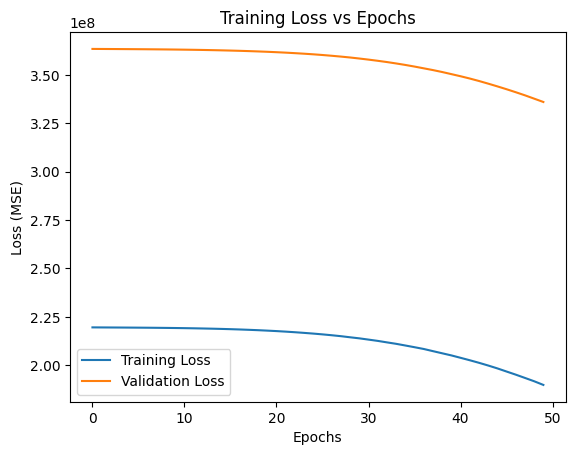

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss vs Epochs")

plt.legend()
plt.show()

In [ ]:
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 13095.025841973282


In [ ]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 245099788.54133293


In [ ]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 15655.66314600991


In [ ]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: -2.104728968834299


In [ ]:
new_car = pd.DataFrame({
    'car_ID':[0],
    'symboling':[0],
    'CarName':['toyota'],
    'fueltype':['gas'],
    'aspiration':['std'],
    'doornumber':['four'],
    'carbody':['sedan'],
    'drivewheel':['fwd'],
    'enginelocation':['front'],
    'wheelbase':[95.7],
    'carlength':[169.7],
    'carwidth':[63.6],
    'carheight':[53.2],
    'curbweight':[2500],
    'enginetype':['ohc'],
    'cylindernumber':['four'],
    'enginesize':[180],
    'fuelsystem':['mpfi'],
    'boreratio':[3.19],
    'stroke':[3.03],
    'compressionratio':[9.0],
    'horsepower':[130],
    'peakrpm':[5000],
    'citympg':[25],
    'highwaympg':[32]
})